<a href="https://colab.research.google.com/github/gapalfaro-cmyk/Proyecto-de-fin-de-modulo-5---Alfaro-Badillo-Cruz-Perez-Rupit/blob/main/Copia_de_Entregable_Tarea_5_3A_Alfaro_Cruz_Perez_Rupit_Medea.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Contaminación Atmosférica y Calidad del Aire (PM2.5)

## Modelos de Ensamble y Redes

Rúbrica: 25% Entrenamiento exitoso de Random Forest, AdaBoost, XGBoost y al menos un Perceptrón Multicapa. Uso de validación cruzada para evitar sobreajuste.

## Resumen de la programación realizada en este código
PENDIENTE

In [ ]:
# Incluir librerías necesarias para procesamiento y graficación
import pandas as pd  # Manejo de datos en tablas
import numpy as np  # Operaciones numéricas
import io   #Gestión de flujos de datos y manejar operaciones de entrada y salida
import requests
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor

In [ ]:
# Importar la información ya limpia y normalizada
df_clean = pd.read_csv("PRSA_data_clean_scaled.csv", sep='\t', encoding='utf-8')

In [ ]:
display(df_clean.head(3))

,NO,YEAR,MONTH,DAY,HOUR,PM25,DEWPOINT,TEMP,PRESION,WIND_DIRECTION,...,WIND_DIRECTION_NE,WIND_DIRECTION_NW,WIND_DIRECTION_SE,WIND_DIRECTION_cv,DEWPOINT_scaled,TEMP_scaled,PRESION_scaled,WIND_SPEED_scaled,SNOW_scaled,RAIN_scaled
0,25,2010,1,2,0,129.0,-16,-4.0,1020.0,SE,...,0.0,0.0,1.0,0.0,-1.229791,-1.347143,0.345329,-0.444944,-0.071057,-0.137408
1,26,2010,1,2,1,148.0,-15,-4.0,1020.0,SE,...,0.0,0.0,1.0,0.0,-1.160508,-1.347143,0.345329,-0.427007,-0.071057,-0.137408
2,27,2010,1,2,2,159.0,-11,-5.0,1021.0,SE,...,0.0,0.0,1.0,0.0,-0.883375,-1.429278,0.442411,-0.409069,-0.071057,-0.137408


In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41757 entries, 0 to 41756
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   NO                 41757 non-null  int64  
 1   YEAR               41757 non-null  int64  
 2   MONTH              41757 non-null  int64  
 3   DAY                41757 non-null  int64  
 4   HOUR               41757 non-null  int64  
 5   PM25               41757 non-null  float64
 6   DEWPOINT           41757 non-null  int64  
 7   TEMP               41757 non-null  float64
 8   PRESION            41757 non-null  float64
 9   WIND_DIRECTION     41757 non-null  object 
 10  WIND_SPEED         41757 non-null  float64
 11  SNOW               41757 non-null  int64  
 12  RAIN               41757 non-null  int64  
 13  FECHA              41757 non-null  object 
 14  FECHA_SIN_H        41757 non-null  object 
 15  WIND_DIRECTION_NE  41757 non-null  float64
 16  WIND_DIRECTION_NW  417

In [ ]:
df_clean.drop(columns=["NO", "YEAR", "MONTH", "DAY", "HOUR","FECHA", "FECHA_SIN_H" ]).describe()

,PM25,DEWPOINT,TEMP,PRESION,WIND_SPEED,SNOW,RAIN,WIND_DIRECTION_NE,WIND_DIRECTION_NW,WIND_DIRECTION_SE,WIND_DIRECTION_cv,DEWPOINT_scaled,TEMP_scaled,PRESION_scaled,WIND_SPEED_scaled,SNOW_scaled,RAIN_scaled
count,41757.000000,41757.000000,41757.000000,41757.000000,41757.000000,41757.000000,41757.000000,41757.000000,41757.000000,41757.000000,41757.000000,4.175700e+04,4.175700e+04,4.175700e+04,4.175700e+04,4.175700e+04,4.175700e+04
mean,98.613215,1.750174,12.401561,1016.442896,23.866747,0.055344,0.194866,0.113897,0.322916,0.348995,0.214192,3.539356e-17,-2.722582e-17,-2.112723e-15,5.445163e-17,8.780325e-17,1.531452e-17
std,92.050387,14.433658,12.175215,10.300733,49.617495,0.778875,1.418165,0.317690,0.467596,0.476658,0.410265,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00
min,0.000000,-40.000000,-19.000000,991.000000,0.450000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-2.892591e+00,-2.579169e+00,-2.470038e+00,-4.719510e-01,-7.105723e-02,-1.374084e-01
25%,29.000000,-10.000000,2.000000,1008.000000,1.790000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-8.140912e-01,-8.543328e-01,-8.196501e-01,-4.449441e-01,-7.105723e-02,-1.374084e-01
50%,72.000000,2.000000,14.000000,1016.000000,5.370000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.730880e-02,1.312878e-01,-4.299705e-02,-3.727913e-01,-7.105723e-02,-1.374084e-01
75%,137.000000,15.000000,23.000000,1025.000000,21.910000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,9.179922e-01,8.705033e-01,8.307377e-01,-3.943711e-02,-7.105723e-02,-1.374084e-01
max,994.000000,28.000000,42.000000,1046.000000,565.490000,27.000000,36.000000,1.000000,1.000000,1.000000,1.000000,1.818676e+00,2.431069e+00,2.869452e+00,1.091610e+01,3.459476e+01,2.524780e+01


In [ ]:
# Seleccionar variables predictoras (X) y variable objetivo (y)
# Excluimos 'NO' (ID) y las columnas de fecha, así como las originales no escaladas/codificadas, para este análisis de regresión.
# Se utiliza df_clean que fue cargado correctamente con el separador de tabulaciones.

features = [
    'WIND_DIRECTION_NE', 'WIND_DIRECTION_NW', 'WIND_DIRECTION_SE', 'WIND_DIRECTION_cv',
    'DEWPOINT_scaled', 'TEMP_scaled', 'PRESION_scaled', 'WIND_SPEED_scaled',
    'SNOW_scaled', 'RAIN_scaled'
]
X = df_clean[features]
y = df_clean['PM25']

In [ ]:
# Se definen las variables para el entrenamiento y prueba de los modelos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print(f"\nDatos de entrenamiento: {X_train.shape[0]} muestras")
print(f"Datos de prueba: {X_test.shape[0]} muestras")


Datos de entrenamiento: 33405 muestras
Datos de prueba: 8352 muestras


## Random Forest

Random Forest utiliza una filosofía de entrenamiento en paralelo basada en el Bagging (Bootstrap Aggregating). Entrena cientos de árboles de decisión independientes al mismo tiempo y, al final, promedia sus predicciones.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

print("\n--- Entrenando Random Forest ---")

# Configurar el modelo
rf_model = RandomForestRegressor(
    n_estimators=100,     # Número de árboles que se entrenarán en paralelo
    max_depth=12,         # Profundidad máxima de cada árbol (pueden ser más profundos que en AdaBoost)
    random_state=42,      # Semilla de reproducibilidad
    n_jobs=-1             # Usa todos los núcleos de tu procesador en paralelo
)

# ntrenar el modelo con los datos meteorológicos
rf_model.fit(X_train, y_train)

# Realizar predicciones y evaluar
y_pred_rf = rf_model.predict(X_test)

print("Métricas para Random Forest:")
print(f"  RMSE (Error en Crisis): {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.2f}")
print(f"  MAE (Error Común): {mean_absolute_error(y_test, y_pred_rf):.2f}")
print(f"  R² Score (Explicación): {r2_score(y_test, y_pred_rf):.4f}")


--- Entrenando Random Forest ---
Métricas para Random Forest:
  RMSE (Error en Crisis): 71.22
  MAE (Error Común): 47.58
  R² Score (Explicación): 0.4243


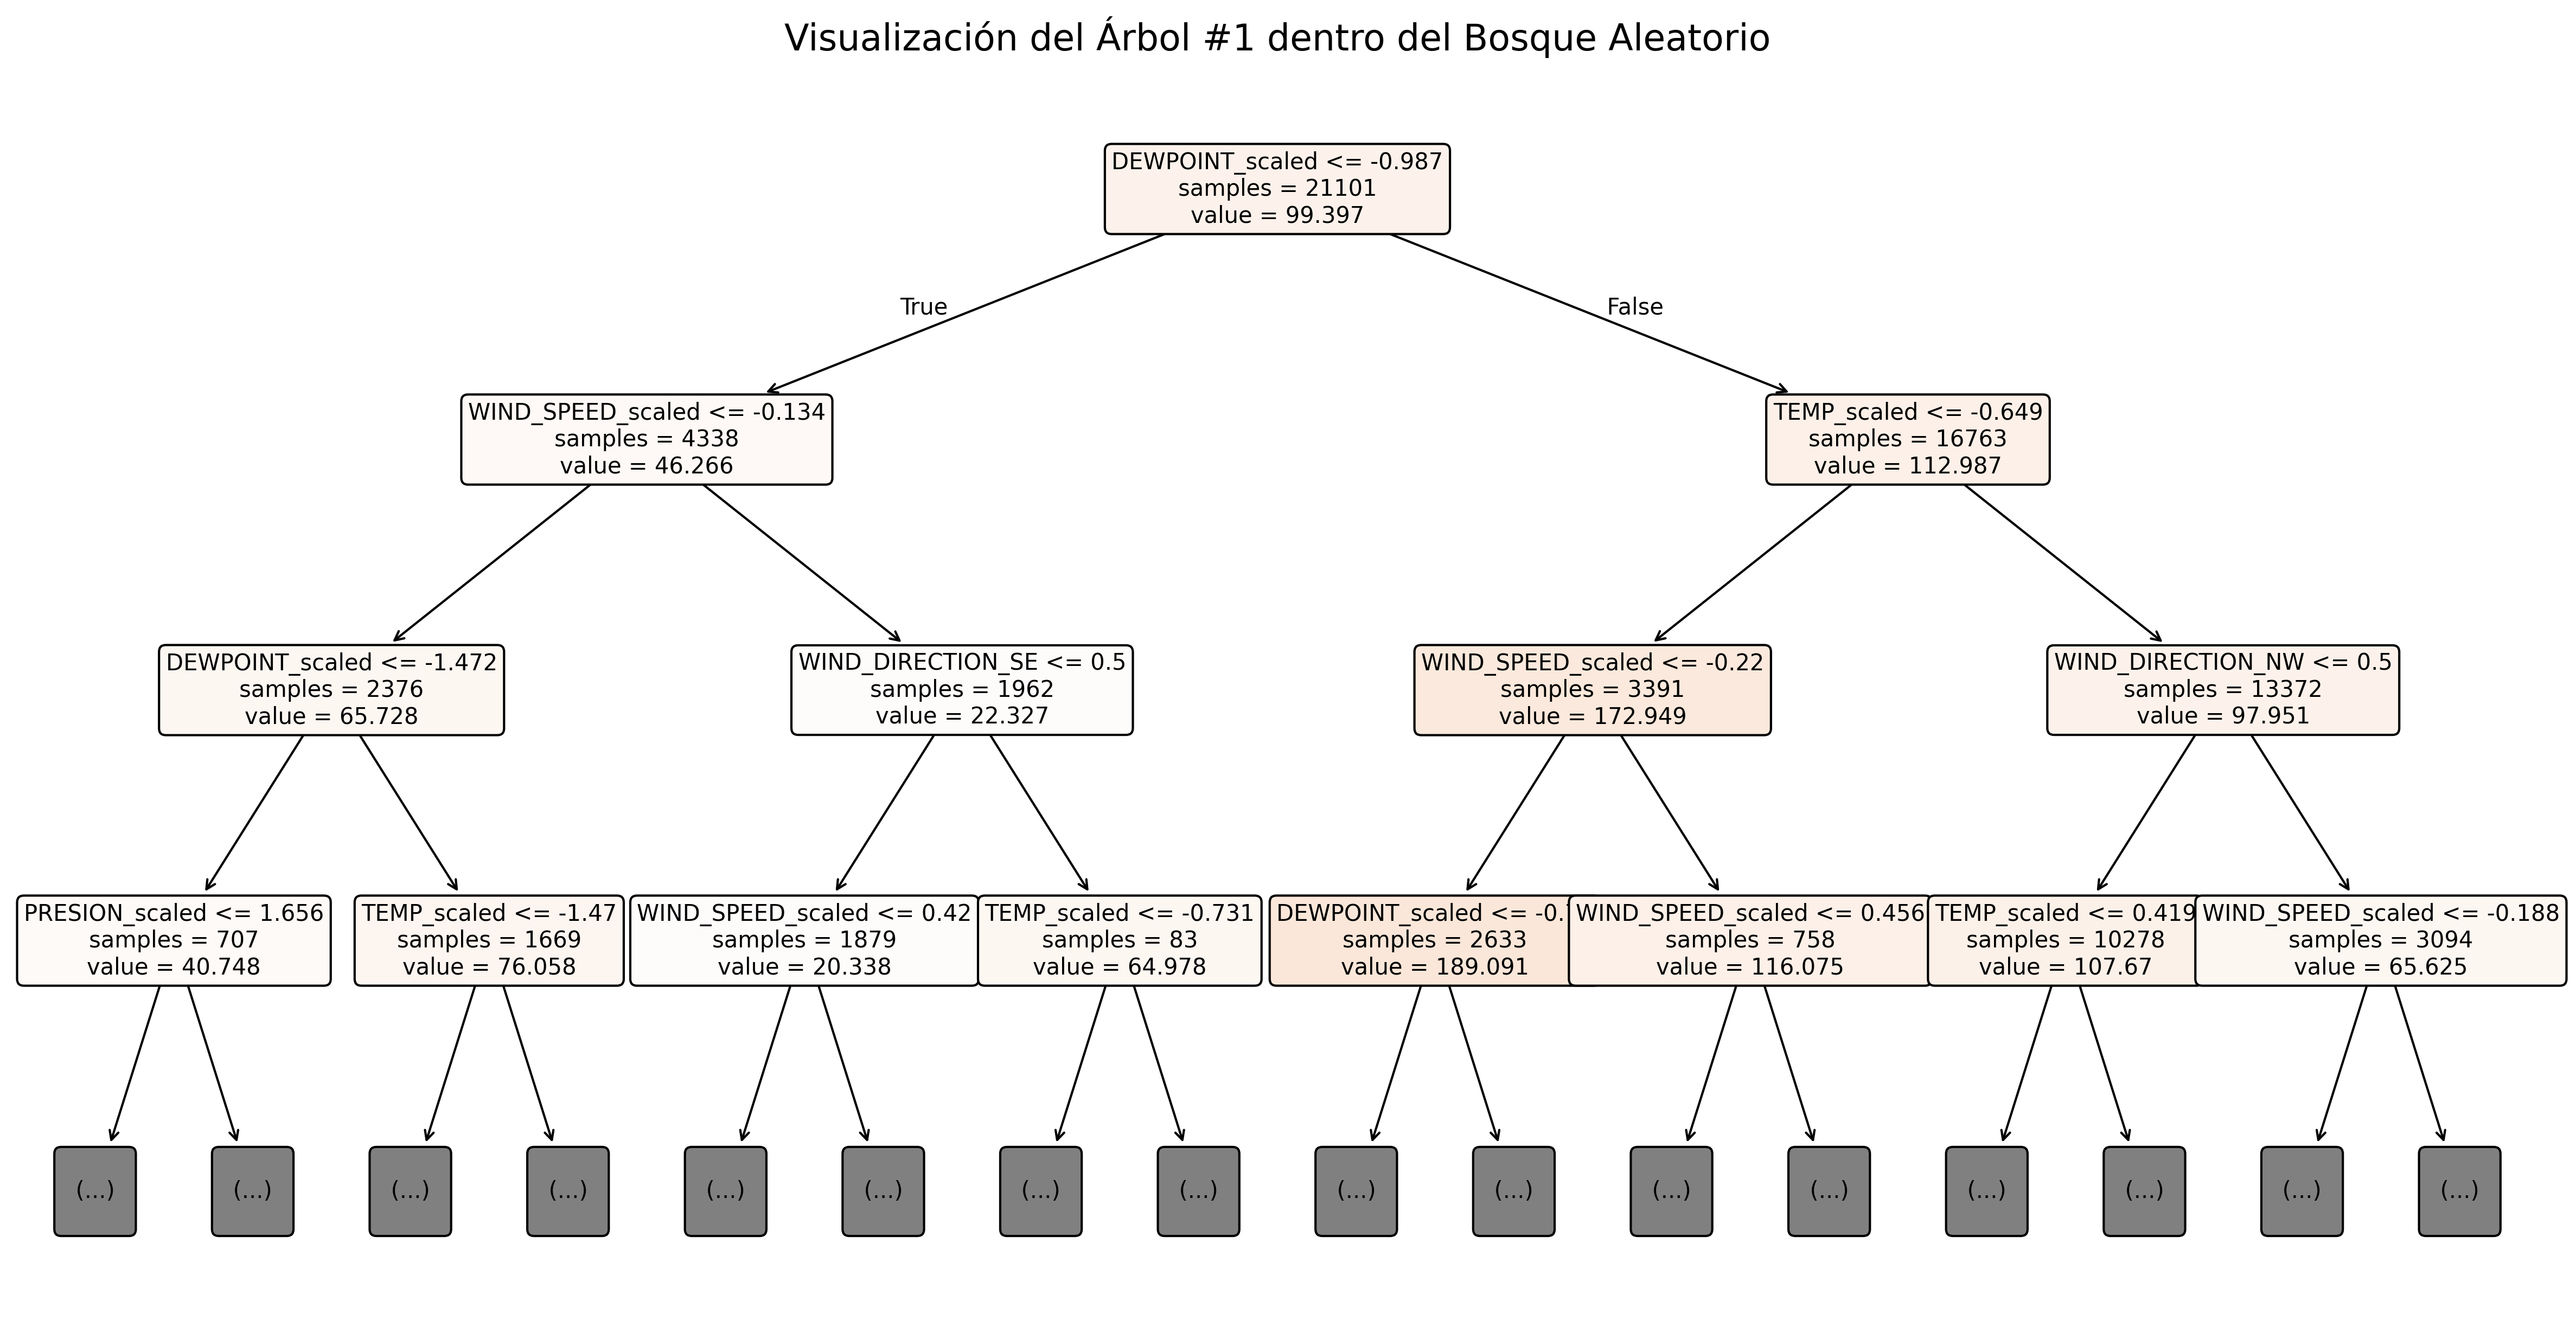

In [ ]:
# Grafica de random forest

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Extraemos el primer árbol (índice 0) del bosque aleatorio
primer_arbol_rf = rf_model.estimators_[0]

plt.figure(figsize=(20, 10), dpi=300)
plot_tree(
    primer_arbol_rf,
    max_depth=3, # Limitamos la visualización porque los árboles de RF suelen ser muy profundos
    feature_names=features,
    filled=True,
    impurity=False,
    rounded=True,
    fontsize=10
)
plt.title("Visualización del Árbol #1 dentro del Bosque Aleatorio", fontsize=16)
plt.show()

## Modelo de Regresión con ADABOOST


Se basa en una estrategia de aprendizaje secuencial. En lugar de entrenar muchos árboles independientes al mismo tiempo (como hace Random Forest), AdaBoost entrena los árboles uno después del otro.

In [ ]:
# --- Modelo de Regresión con ADABOOST ---
print("\n--- Entrenando AdaBoost ---")
# Usamos un DecisionTreeRegressor como aprendiz débil (weak learner).
# En regresión, es común darle un poco más de profundidad que 1 para capturar interacciones.
weak_learner = DecisionTreeRegressor(max_depth=6)
adaboost_model = AdaBoostRegressor(estimator=weak_learner, n_estimators=100, learning_rate=0.1, random_state=42)
adaboost_model.fit(X_train, y_train)


--- Entrenando AdaBoost ---


AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=6),
                  learning_rate=0.1, n_estimators=100, random_state=42)

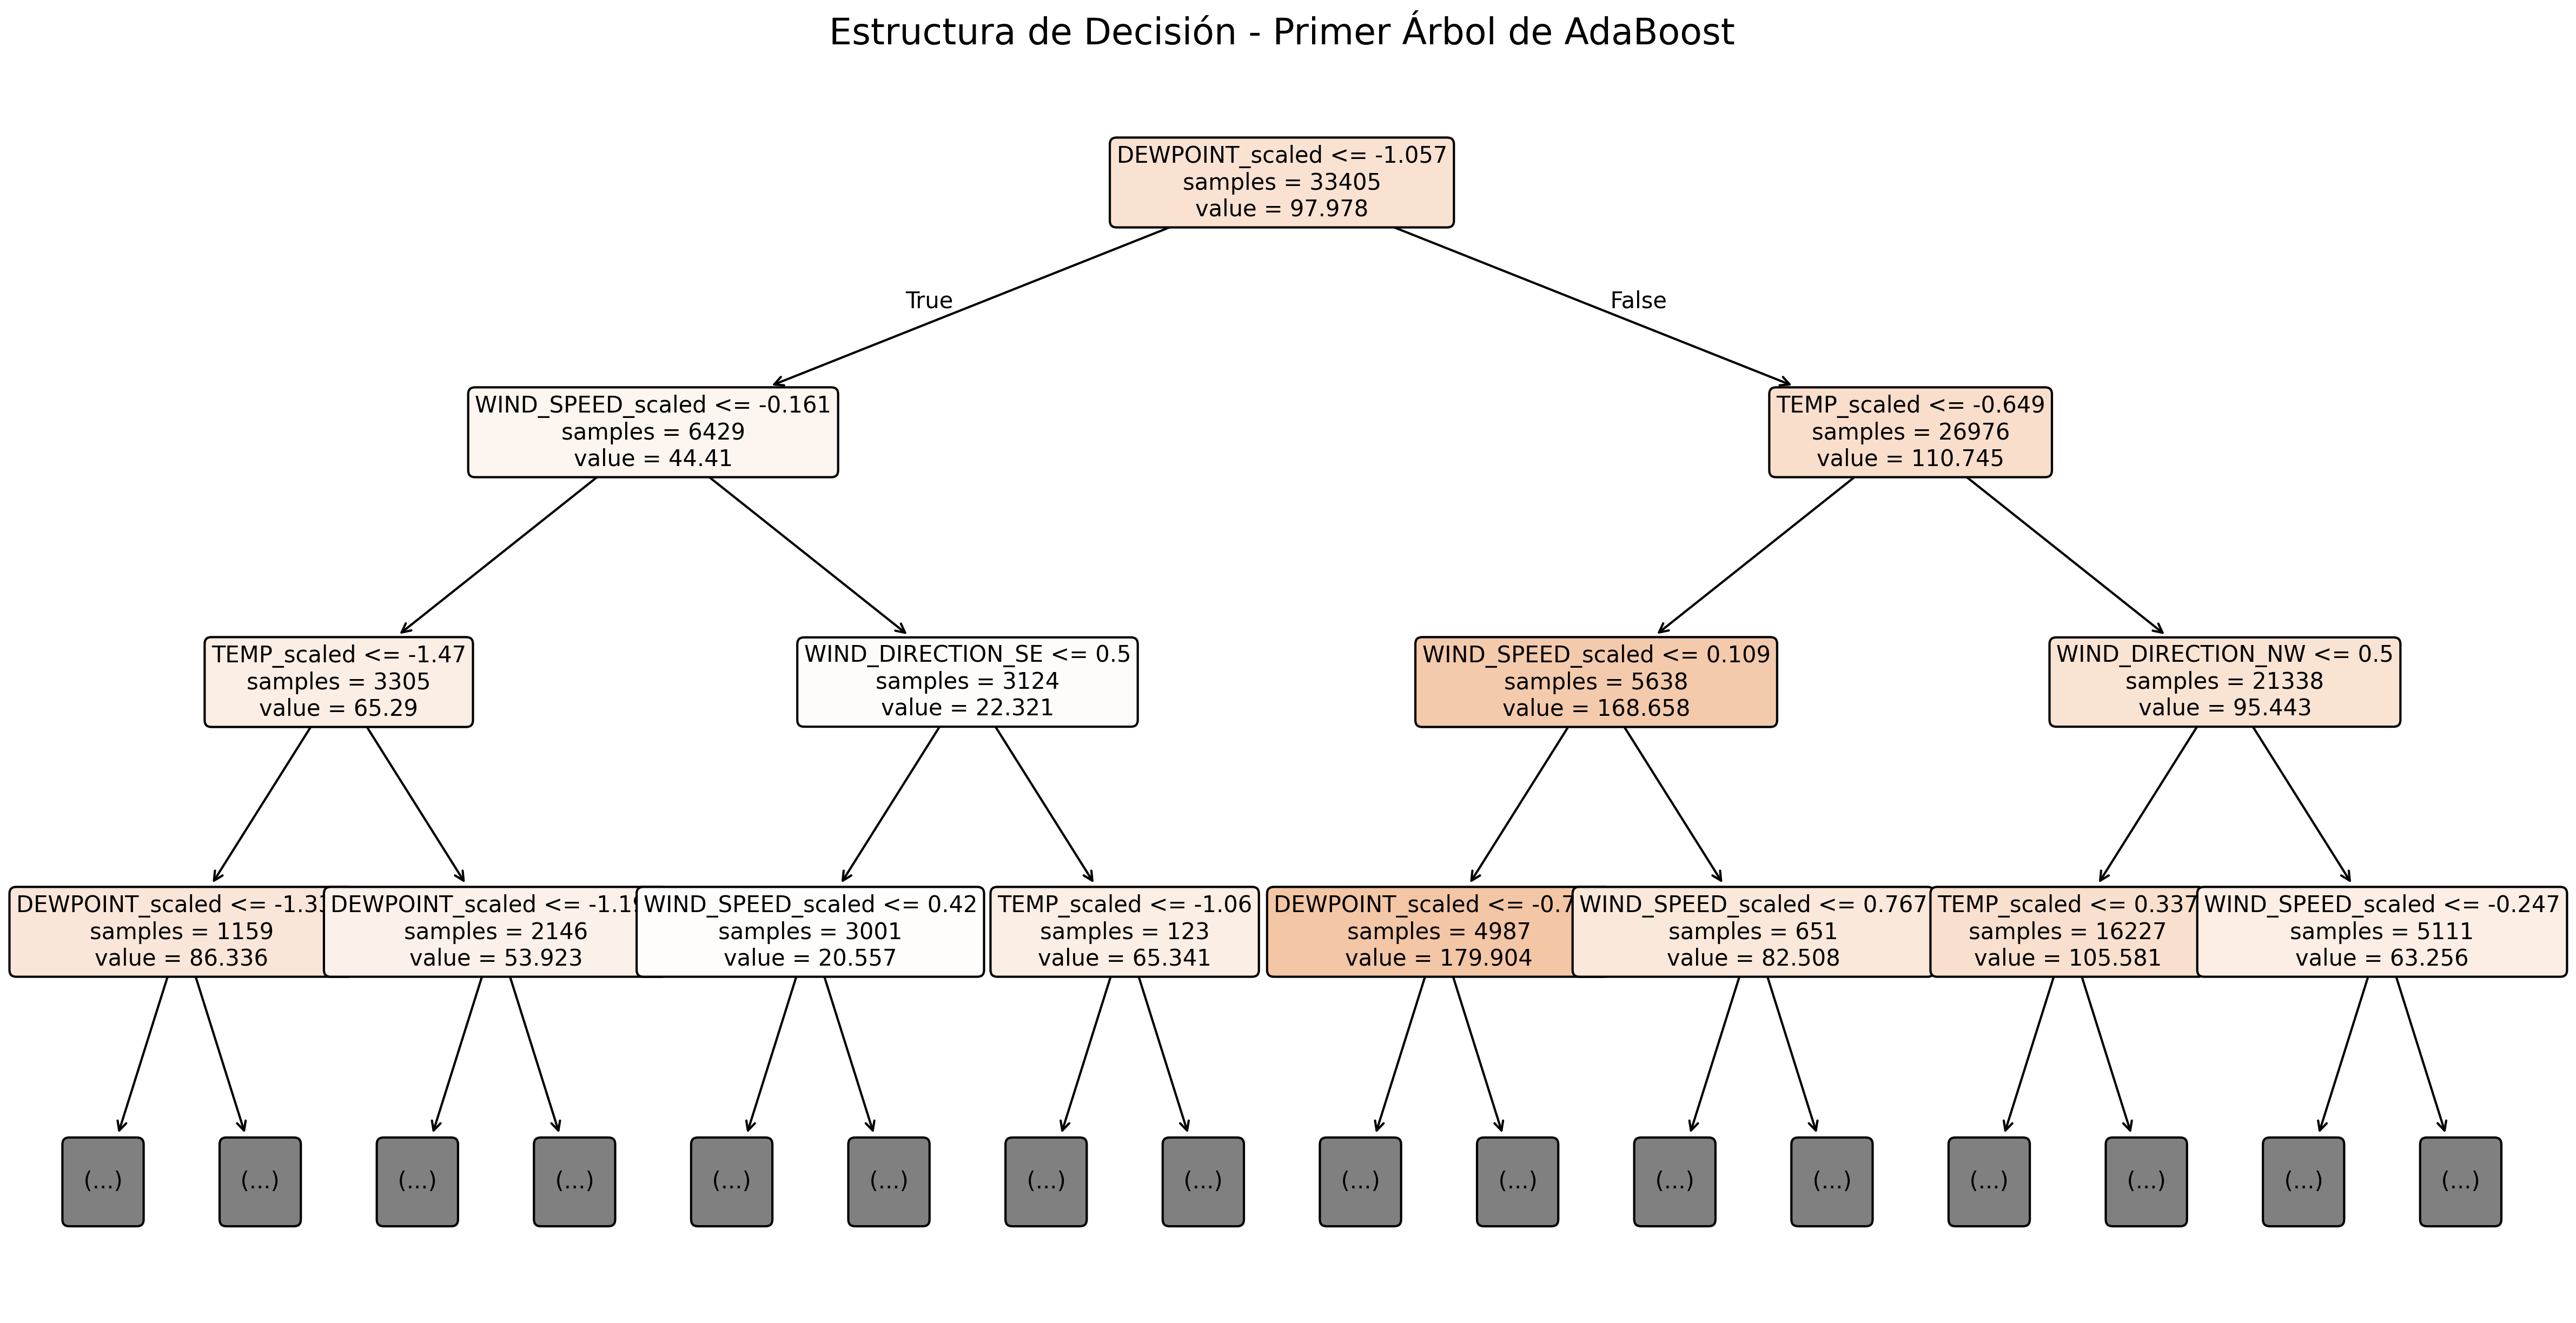

In [ ]:
# Graficar el primer arbol de decisión

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree, export_text

# (El índice 0 representa el árbol inicial antes de la actualización de pesos)
primer_arbol = adaboost_model[0]

# Configuramos una gráfica grande (20x10 pulgadas) y alta resolución (dpi=300)
# para que las letras no se amontonen y sean legibles.
plt.figure(figsize=(20, 10), dpi=300)

plot_tree(
    primer_arbol,
    max_depth=3,            # Limitamos a 3 niveles para que sea humanamente legible
    feature_names=features,  # Lista con los nombres de las variables meteorológicas
    filled=True,             # Pinta los nodos (tonos oscuros = alta contaminación)
    impurity=False,          # Oculta el valor del MSE para limpiar el diseño
    rounded=True,            # Bordes redondeados en los bloques de decisión
    fontsize=10              # Tamaño de la fuente dentro de los nodos
)

plt.title("Estructura de Decisión - Primer Árbol de AdaBoost", fontsize=16)
plt.savefig("mi_arbol_scikit.png", bbox_inches='tight') # Guarda el diagrama en tu computadora
plt.show()

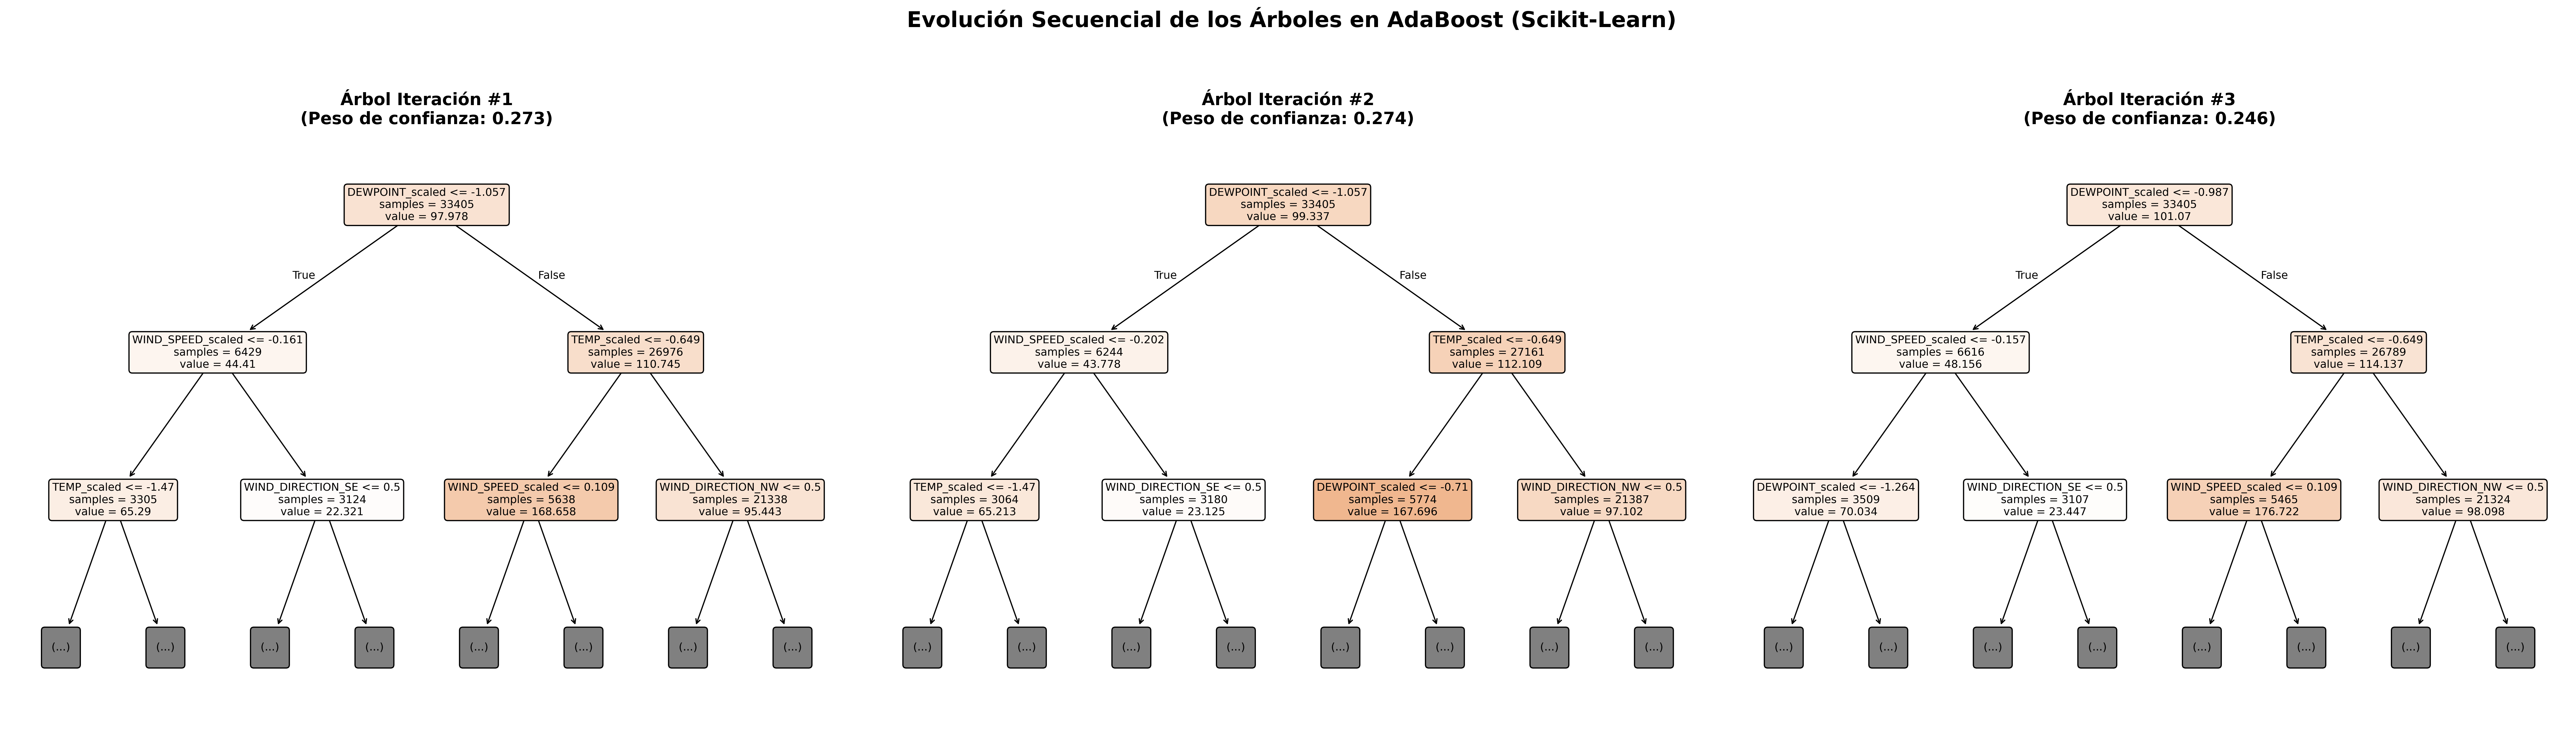

In [ ]:
#Graficar los arboles de decisión secuenciales

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Definimos cuántos árboles queremos graficar (ej: los primeros 3)
n_arboles_a_graficar = 3

# Creamos el grafico dividido en subgráficas (1 fila, 3 columnas)
# Usamos un tamaño muy ancho (30x8 pulgadas) para que no se amontone el texto
fig, axes = plt.subplots(nrows=1, ncols=n_arboles_a_graficar, figsize=(30, 8), dpi=300)

# Iteramos para pintar cada árbol usando los atributos de Scikit-Learn
for i in range(n_arboles_a_graficar):
    # Extraemos el árbol usando '.estimators_' de Scikit-Learn
    arbol_actual = adaboost_model.estimators_[i]

    # Seleccionamos el espacio de la cuadrícula (eje) actual
    ax_actual = axes[i]

    # Pintamos el árbol
    plot_tree(
        arbol_actual,
        max_depth=2,              # Profundidad 2 para mantenerlo limpio y legible
        feature_names=features,    # Variables meteorológicas de Beijing
        filled=True,               # Se colorean los nodos según el nivel de PM2.5
        impurity=False,            # Ocultar el MSE para limpiar el diseño
        rounded=True,              # Bordes redondeados
        fontsize=9,                # Letra compacta pero legible
        ax=ax_actual               # Dibujar en la subgráfica correspondiente
    )

    # Recuperamos el peso usando '.estimator_weights_' de Scikit-Learn
    peso_arbol = adaboost_model.estimator_weights_[i]
    ax_actual.set_title(f"Árbol Iteración #{i+1}\n(Peso de confianza: {peso_arbol:.3f})", fontsize=14, fontweight='bold')

# Damos formato al gráfico
plt.suptitle("Evolución Secuencial de los Árboles en AdaBoost (Scikit-Learn)", fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()

# Guardar la imagen
plt.savefig("secuencia_arboles_scikit_adaboost.png", bbox_inches='tight')
plt.show()

## Modelo de Regresión con XGBOOST

In [ ]:
# --- ENFOQUE 2: XGBOOST REGRESSOR ---
print("--- Entrenando XGBoost ---")
xgboost_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1)
xgboost_model.fit(X_train, y_train)

--- Entrenando XGBoost ---


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=-1, num_parallel_tree=None, ...)

/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


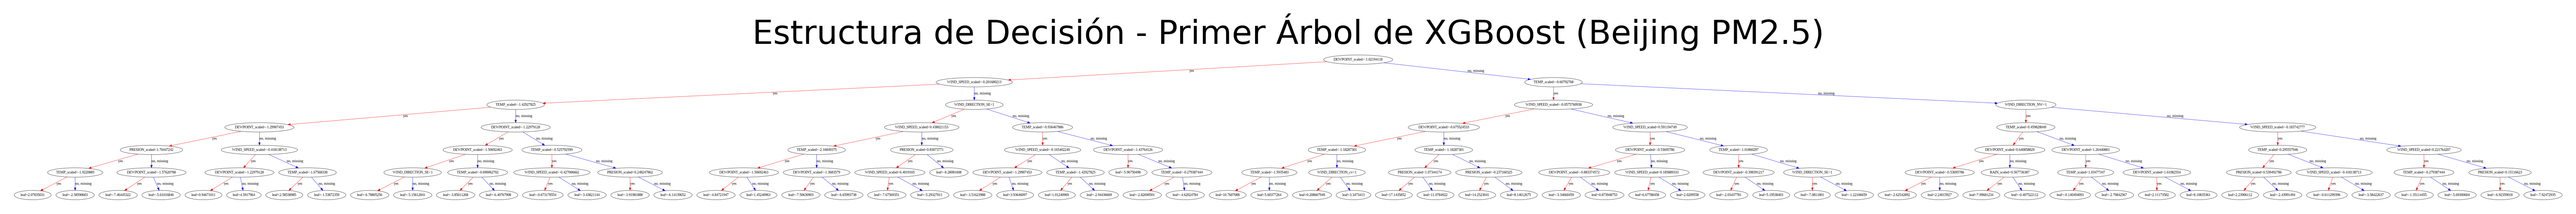

In [ ]:
import matplotlib.pyplot as plt
import xgboost as xgb

# El modelo debe tener los nombres de las variables
# (XGBoost usa estos nombres para etiquetar los nodos en la gráfica automáticamente)
xgboost_model.feature_names = features

# Configurar el modelo de decisión de Matplotlib
# Los árboles de XGBoost suelen ser anchos, por lo que la vista grande es vital.
fig, ax = plt.subplots(figsize=(25, 12), dpi=300)

# 3. Graficar el árbol usando la herramienta nativa de XGBoost
xgb.plot_tree(
    xgboost_model,
    num_trees=0,        # 0 significa el PRIMER árbol del ensamble (el más importante)
    ax=ax,              # Le pasamos el modelo de decisión de matplotlib que creamos arriba
    rankdir='TB'        # 'TB' = Top-to-Bottom (Arriba a abajo). Puedes cambiarlo a 'LR' (Left-to-Right)
)

# Ajustes estéticos y guardar
plt.title("Estructura de Decisión - Primer Árbol de XGBoost (Beijing PM2.5)", fontsize=18)
plt.savefig("arbol_xgboost.png", bbox_inches='tight')
plt.show()

## Resultados ADABOOST y XGBOOST

In [ ]:
# EVALUACIÓN DE LOS MODELOS
def evaluar_modelo(modelo, name, X_test, y_test):
    predictions = modelo.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    print(f"\nMétricas para {name}:")
    print(f"  RMSE (Error Cuadrático Medio Ríz): {rmse:.2f}")
    print(f"  MAE (Error Absoluto Medio): {mae:.2f}")
    print(f"  R² Score (Coeficiente de Determinación): {r2:.4f}")
    return predictions

y_pred_ada = evaluar_modelo(adaboost_model, "AdaBoost", X_test, y_test)
y_pred_xgb = evaluar_modelo(xgboost_model, "XGBoost", X_test, y_test)


Métricas para AdaBoost:
  RMSE (Error Cuadrático Medio Ríz): 80.08
  MAE (Error Absoluto Medio): 59.82
  R² Score (Coeficiente de Determinación): 0.2723

Métricas para XGBoost:
  RMSE (Error Cuadrático Medio Ríz): 71.83
  MAE (Error Absoluto Medio): 48.36
  R² Score (Coeficiente de Determinación): 0.4144


In [ ]:
# 5. IMPORTANCIA DE LAS VARIABLES
importancias = pd.DataFrame({
    'Variable': features,
    'Importancia_AdaBoost': adaboost_model.feature_importances_,
    'Importancia_XGBoost': xgboost_model.feature_importances_
}).sort_values(by='Importancia_XGBoost', ascending=False)

print("\nImportancia de las variables climáticas:")
print(importancias.to_string(index=False))


Importancia de las variables climáticas:
         Variable  Importancia_AdaBoost  Importancia_XGBoost
WIND_DIRECTION_NW              0.012032             0.187434
      TEMP_scaled              0.345875             0.164438
  DEWPOINT_scaled              0.296419             0.161733
WIND_DIRECTION_SE              0.028545             0.144713
WIND_SPEED_scaled              0.178356             0.114252
WIND_DIRECTION_NE              0.000942             0.058018
   PRESION_scaled              0.128996             0.051755
      RAIN_scaled              0.002002             0.043926
      SNOW_scaled              0.004335             0.037483
WIND_DIRECTION_cv              0.002497             0.036249


## Modelo Perceptrón Multicapa (MLP, por sus siglas en inglés) Red Neuronal Artificial (Deep Learning)

Un MLP utiliza capas de neuronas matemáticas interconectadas que aplican funciones de activación no lineales. Esto le permite aproximar cualquier función compleja y encontrar relaciones continuas y sumamente sutiles entre el clima y la contaminación por $\text{PM}_{2.5}$.

Usaremos la versión de Scikit-Learn en el modelo

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# Las redes neuronales SON HIPERSENSIBLES a la escala de los datos.
# A diferencia de los árboles, si no escalas las variables (TEMP, PRES, etc.), el MLP fallará.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n--- Entrenando Perceptrón Multicapa (MLP) ---")

# Configuración de la Red Neuronal
mlp_model = MLPRegressor(
    hidden_layer_sizes=(64, 32), # Dos capas ocultas: la primera con 64 neuronas, la segunda con 32
    activation='relu',           # Función de activación no lineal ReLU
    solver='adam',               # Optimizador robusto para ajustar los pesos
    max_iter=500,                # Máximo de épocas de entrenamiento
    early_stopping=True,         # Detiene el entrenamiento si deja de mejorar (evita overfitting)
    random_state=42
)

# Entrenar
mlp_model.fit(X_train_scaled, y_train)

# Evaluar
y_pred_mlp = mlp_model.predict(X_test_scaled)
print("Métricas para MLP:")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_mlp)):.2f}")
print(f"  MAE: {mean_absolute_error(y_test, y_pred_mlp)}:.2f")
print(f"  R² Score: {r2_score(y_test, y_pred_mlp):.4f}")


--- Entrenando Perceptrón Multicapa (MLP) ---
Métricas para MLP:
  RMSE: 74.29
  MAE: 50.66653821264984:.2f
  R² Score: 0.3736


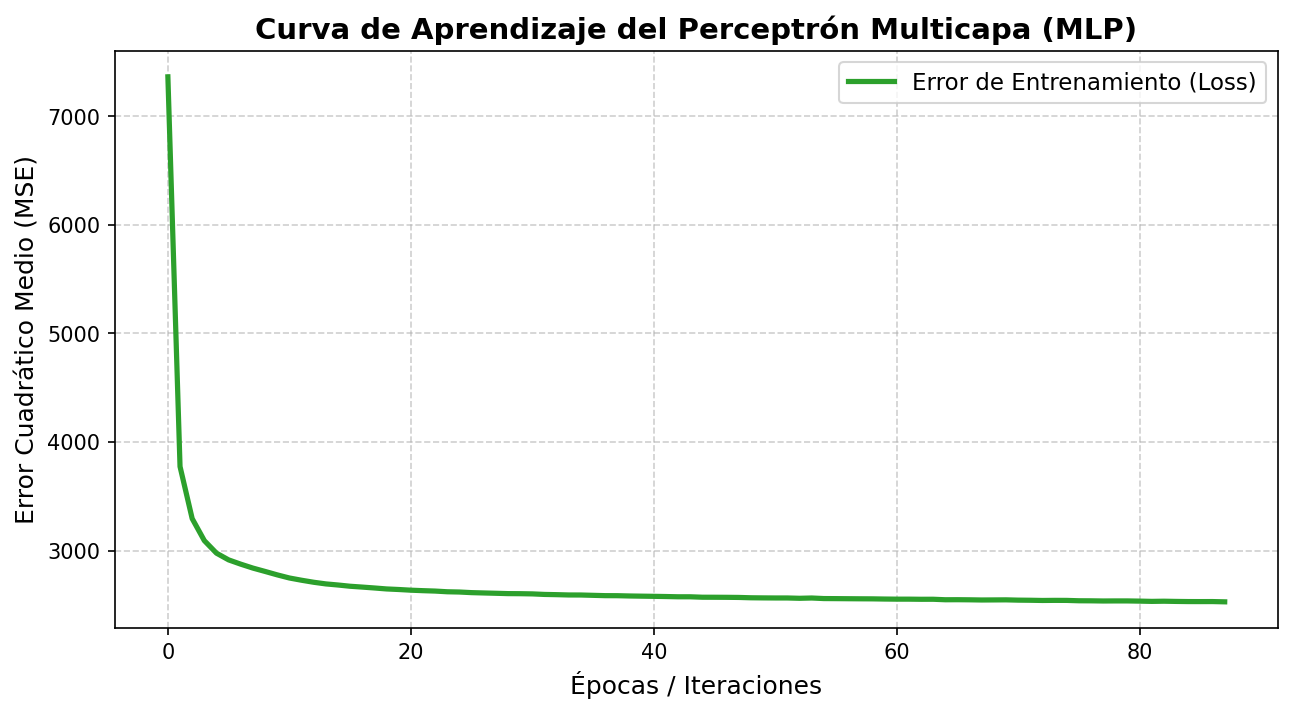

In [ ]:
#Graficar la Curva de Pérdida

import matplotlib.pyplot as plt

# Configuramos el tamaño de la gráfica
plt.figure(figsize=(10, 5), dpi=150)

# Mostrar la curva de pérdida extraída del modelo MLP entrenado
plt.plot(mlp_model.loss_curve_, color='#2ca02c', linewidth=2.5, label='Error de Entrenamiento (Loss)')

# Damos formato a la gráfica
plt.title('Curva de Aprendizaje del Perceptrón Multicapa (MLP)', fontsize=14, fontweight='bold')
plt.xlabel('Épocas / Iteraciones', fontsize=12)
plt.ylabel('Error Cuadrático Medio (MSE)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

# Extraer gráfica
plt.savefig("curva_perdida_mlp.png", bbox_inches='tight')
plt.show()

Interpretación de la gráfica

Al principio, la curva empezará muy arriba (un error alto porque los pesos eran aleatorios) y caerá drásticamente en las primeras épocas. La configuración funcionó ya que la curva se vuelve completamente plana (asíntota) justo antes de que el entrenamiento se detenga de golpe.

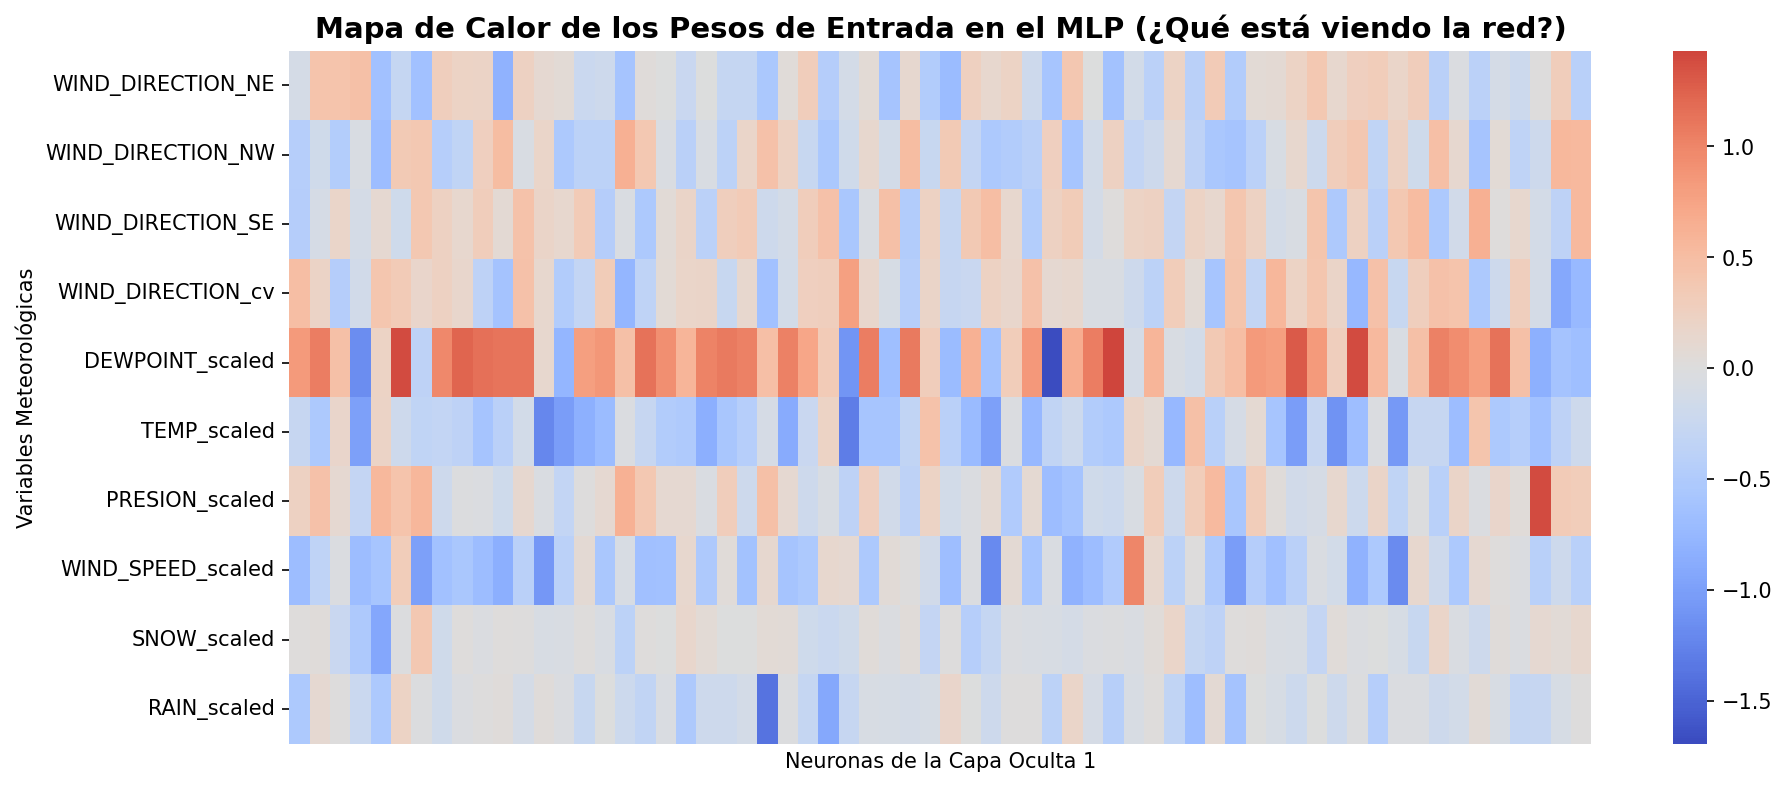

In [ ]:
# Pintamos el Diagrama de la Red Neuronal
import seaborn as sns

# Extraemos la matriz de pesos que conecta las variables de entrada con la Capa Oculta 1
# Tiene una dimensión de (Número de variables x 64 neuronas)
pesos_entrada = mlp_model.coefs_[0]

plt.figure(figsize=(14, 6), dpi=150)

# Creamos un mapa de calor (Heatmap)
sns.heatmap(
    pesos_entrada,
    cmap='coolwarm',          # Azul = Peso negativo, Rojo = Peso positivo
    yticklabels=features,     # Las variables meteorológicas (TEMP, Iws, etc.)
    xticklabels=False,        # Ocultamos el eje X (las 64 neuronas) para no saturar
    center=0
)

plt.title('Mapa de Calor de los Pesos de Entrada en el MLP (¿Qué está viendo la red?)', fontsize=14, fontweight='bold')
plt.ylabel('Variables Meteorológicas')
plt.xlabel('Neuronas de la Capa Oculta 1')
plt.show()

Interpretación de la gráfica

 Cada línea horizontal representa una variable climática (como la velocidad del viento). Si una línea tiene muchos cuadros rojos intensos o azules oscuros, significa que esa variable está estimulando fuertemente a las neuronas de la red para predecir el $\text{PM}_{2.5}$ (es una variable muy importante). Si una línea es completamente gris o pálida, esa variable está pasando desapercibida por el motor del modelo.

## Conclusión














In [ ]:
# Matriz con los resultados de los 4 modelos
import pandas as pd

# Creamos el diccionario definitivo con los 4 modelos competidores
datos_definitivos = {
    "Métrica": [
        "R² Score (Capacidad de Explicación)",
        "MAE (Error Promedio Común)",
        "RMSE (Error en Picos de Crisis)"
    ],
    "AdaBoost": [
        "27.23%",
        "59.82 µg/m³",
        "80.08"
    ],
    "MLP (Red Neuronal)": [
        "37.36%",
        "50.66 µg/m³",
        "74.29"
    ],
    "Random Forest": [
        "42.43%",
        "47.58 µg/m³",
        "71.22"
    ],
    "XGBoost": [
        "41.44% (El Ganador)",
        "48.36 µg/m³",
        "71.83"
    ]
}

# Convertimos en DataFrame de Pandas
df_final = pd.DataFrame(datos_definitivos)

# Si estás en Jupyter Notebook, solo escribe df_final para verla estilizada
print(df_final.to_string(index=False))

                            Métrica    AdaBoost MLP (Red Neuronal) Random Forest             XGBoost
R² Score (Capacidad de Explicación)      27.23%             37.36%        42.43% 41.44% (El Ganador)
         MAE (Error Promedio Común) 59.82 µg/m³        50.66 µg/m³   47.58 µg/m³         48.36 µg/m³
    RMSE (Error en Picos de Crisis)       80.08              74.29         71.22               71.83


Si ordenamos los modelos de mejor a peor según su rendimiento, el podio queda así: Random Forest (1º) > XGBoost (2º) > MLP (3º) > AdaBoost (4º).


* Random Forest logra explicar el 42.43% de la variabilidad de las partículas $\text{PM}_{2.5}$ en Beijing. Superó a XGBoost ($41.44\%$) por un $1\%$. Aunque suena a poco, en ciencia de datos rascar un punto porcentual extra de un dataset tan ruidoso usando variables puramente meteorológicas es un logro importante.
El menor error en días comunes (MAE de $47.58\ \mu\text{g/m}^3$): En el día a día, las predicciones de Random Forest son las más cercanas a la realidad de todo tu experimento, superando a XGBoost por casi una unidad completa.


* El dato más contundente de tu tabla es el RMSE. Esta métrica eleva los errores al cuadrado, por lo que castiga de forma despiadada a los modelos que cometen fallos catastróficos (como predecir aire limpio en un día de contingencia ambiental severa).Random Forest ($71.22$) vs. XGBoost ($71.83$) vs. AdaBoost ($80.08$): Que Random Forest tenga el RMSE más bajo de todos significa que su estrategia de promediar 100 árboles independientes amortigua mejor los picos salvajes e impredecibles de contaminación de Beijing. Al "votar en masa", los árboles del bosque neutralizan los errores individuales extremos, algo que a los algoritmos de Boosting les cuesta más trabajo controlar debido a su naturaleza secuencial.



Escogemos Random Forest porque demostró empíricamente ser el modelo más robusto, preciso y confiable para este problema específico de calidad del aire. Además, tiene una ventaja operativa enorme: no requiere escalado de datos (como el MLP) y es sumamente noble, entregándote el mejor rendimiento del proyecto prácticamente "salido de la caja".